<a href="https://colab.research.google.com/github/SakheBell/Python-Projects/blob/main/1907146.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:#003B7A;color:white;padding:20px;border-bottom:6px solid #FFC000"><h1>Assignment 1 · Geochemical database audit and anomaly investigation</h1><p>Prof. Glen Nwaila · GEOL5013A · 2026</p></div>

**20 marks · Individual work · Due 27 September 2026, 23:59 SAST**

## Where this fits in the course

Weeks 1–2 teach how observations become a trustworthy database and how exploratory methods identify records needing investigation. This assignment is the first assessed checkpoint. Later work on distributions, variograms and geological models depends on the records, units and joins being defensible.

## Why you are doing this assignment

A plausible-looking prediction can still be wrong if it uses mismatched sample identifiers, coordinate systems or assay units. Here you investigate real rows and justify decisions before modelling. An unusual value is a question to investigate, not an automatic error.

## Intended learning outcomes

- Audit two geochemical tables while preserving raw values and metadata.
- Join records without losing or duplicating their identity.
- Compare anomaly evidence under two justified analytical choices.
- Explain a data decision using identifiable records and reproducible calculations.

## What is supplied and what you must add

Two supplied Strange Lake Excel workbooks, a data/code ZIP and a notebook with baseline audit, join and Isolation Forest code. The baseline is a starting point. You must add the checks, alternative analysis, output tables and written answers below.

Read **A1_Brief_and_Rubric.docx** (or its identical PDF) before running. All assessed questions are repeated below. Run the setup cell first, upload Homework_Data_and_Code.zip when requested, and set your student number. Keep supplied baseline code, then add your own experiments in the marked code cells and written answers in the response cells. Running the baseline alone does not answer the questions.


In [1]:
import os; print(os.getcwd())
LESSON='A1_Geochemical_Database'
from pathlib import Path
import sys, zipfile, json, hashlib
ROOT=Path(os.getcwd()).resolve()
if not (ROOT/'teaching_methods.py').exists():
    from google.colab import files
    print('Upload Homework_Data_and_Code.zip from the Assignments folder.')
    upload=files.upload()
    archives=[ROOT/name for name in upload if name.endswith('.zip')]
    assert len(archives)==1, 'Upload exactly one homework data ZIP.'
    with zipfile.ZipFile(archives[0]) as archive:
        for member in archive.namelist():
            assert (ROOT/member).resolve().is_relative_to(ROOT)
        archive.extractall(ROOT)
sys.path.insert(0,str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from teaching_methods import *
STUDENT_NUMBER='1907146' # Replace with your own student number before the first run.
SEED=2026+int(''.join(c for c in STUDENT_NUMBER if c.isdigit())[-4:])
DATA=ROOT/'Homework_Data'
OUT=Path(os.getcwd())/'Outputs'/LESSON
OUT.mkdir(parents=True,exist_ok=True)
rng=np.random.default_rng(SEED)
def save_figure(fig,name):
    for ext in ['png','pdf']:fig.savefig(OUT/f'{name}.{ext}',dpi=180,bbox_inches='tight')
    plt.show()
manifest={'student_number':STUDENT_NUMBER,'seed':SEED,'numpy':np.__version__,'pandas':pd.__version__,
          'inputs':{p.name:hashlib.sha256(p.read_bytes()).hexdigest() for p in DATA.iterdir() if p.is_file()}}
(OUT/'run_manifest.json').write_text(json.dumps(manifest,indent=2))
print('Output directory:',OUT)


/content
Output directory: /content/Outputs/A1_Geochemical_Database


<h2 style="color:#003B7A;border-left:6px solid #FFC000;padding-left:12px">Q1. What must be checked before these tables can be used? · 5 marks</h2>

**Q1.1.** Inspect both workbooks before cleaning. Record dimensions, candidate key, coordinate columns, chemical columns and metadata rows. Preserve the new workbook’s units row separately. Distinguish a missing-key metadata row from a sample with a missing identifier.

**Q1.2.** Make data_dictionary.csv for the sample key, both coordinate pairs and five chemical variables you choose. Include workbook, original column name, meaning, recorded unit, coordinate reference where applicable, source of the definition and any unresolved assumption.

**Q1.3.** Count missing keys, duplicate keys, missing values and nonnumeric or censored entries in the selected chemical columns. Save audit.csv with workbook, check, affected column, count and proposed action. Keep original strings beside any numerical replacement. A zero finding must still be recorded.

**Q1.4.** In 150–200 words, identify the two findings that most affect later analysis. Cite actual columns and counts and explain whether you would retain, query or correct them. Do not guess undocumented units.

**Marking criteria:** Dictionary and metadata: 2; implemented checks and counts: 2; interpretation of consequences: 1.

**What good work looks like:** A reader can locate the cited raw rows, see the original units and reproduce each audit count. The explanation distinguishes observations from assumptions.


<h2 style="color:#003B7A">1. Inspect the raw tables</h2>

The new workbook contains a units row. Preserve it before selecting sample records. A record without a sample key is not automatically a sample with missing data.

**Expected output and check:** Check row counts, key uniqueness and the units row. Do not assume the old and new assays use identical methods or units.


In [2]:
old=pd.read_excel(DATA/'Strange_Lake_OLD.xlsx')
new_raw=pd.read_excel(DATA/'Strange_Lake_NEW.xlsx')
metadata_rows=new_raw[new_raw['Unique ID'].isna()].copy()
new=new_raw[new_raw['Unique ID'].notna()].copy()
metadata_rows.to_csv(OUT/'new_workbook_metadata_rows.csv',index=False)
audit=pd.DataFrame([{'table':name,'rows':len(df),'missing_keys':int(df['Unique ID'].isna().sum()),'duplicate_keys':int(df['Unique ID'].duplicated().sum())} for name,df in [('old',old),('new_samples',new)]])
audit.to_csv(OUT/'audit.csv',index=False)
display(audit,metadata_rows,old.head(),new.head())


,table,rows,missing_keys,duplicate_keys
0,old,3441,0,0
1,new_samples,3441,0,0


,Unique ID,Sample Type,NTS,Latitude (NAD 27),Longitude (NAD 27),Ag,Al,As,Au,B,...,Ti,Tl,Tm,U,V,W,Y,Yb,Zn,Zr
0,NaN,NaN,NaN,NaN,NaN,PPB,%,PPM,PPB,PPM,...,%,PPM,PPM,PPM,PPM,PPM,PPM,PPM,PPM,PPM


,Unique ID,NTS Sheet,Latitude_NAD83,Longitude_NAD83,Zn,Cu,Pb,Ni,Co,Ag,Mn,Fe,As,Mo,F,LOI,Hg,U
0,013L781002,013L,54.989093,-62.019071,40,38,<2,43,10,<0.2,70,1.00,<1,2,85,23,40,0.3
1,013L781003,013L,54.975382,-62.030577,40,44,<2,35,8,<0.2,80,1.90,<1,<2,80,33,70,0.5
2,013L781004,013L,54.976331,-62.044913,46,30,<2,34,8,<0.2,80,0.70,<1,2,90,27.2,50,0.6
3,013L781005,013L,54.973541,-62.054790,50,26,<2,22,6,<0.2,120,0.85,<1,2,60,29.6,40,0.6
4,013L781007,013L,54.936983,-62.026399,42,20,<2,22,9,<0.2,100,0.70,<1,2,65,33.6,60,0.3


,Unique ID,Sample Type,NTS,Latitude (NAD 27),Longitude (NAD 27),Ag,Al,As,Au,B,...,Ti,Tl,Tm,U,V,W,Y,Yb,Zn,Zr
1,013L781002,Routine,013L,54.98900,-62.01995,57,2.89,<0.1,1,<20,...,0.021,0.03,0.1,0.3,31,<0.1,6.04,0.64,44,0.9
2,013L781003,Routine,013L,54.97529,-62.03145,106,3.22,0.1,1.6,<20,...,0.021,0.03,0.08,0.3,45,<0.1,5.65,0.49,45.1,1
3,013L781004,Routine,013L,54.97623,-62.04579,59,2.34,0.1,1.1,<20,...,0.023,0.04,0.09,0.3,17,<0.1,7.19,0.64,51.4,0.8
4,013L781005,First Field Duplicate,013L,54.97344,-62.05566,70,2.26,0.1,0.9,<20,...,0.014,0.03,0.12,0.6,34,<0.1,8.08,0.74,51.1,0.8
5,013L781007,Routine,013L,54.93689,-62.02727,62,1.89,<0.1,0.3,<20,...,0.021,0.05,0.1,0.3,28,<0.1,7.53,0.61,45.4,0.9


In [3]:
# Add your Q1 checks, experiments and required file exports here.
# Use OUT for saved tables and PDF/PNG figures.

DATA = Path('Homework_Data')
OUT = Path('Outputs'); OUT.mkdir(exist_ok=True)
CHEMICALS = ['Cu', 'Zn', 'U', 'Pb', 'As']

# Q1.1:
old = pd.read_excel(DATA/'Strange_Lake_OLD.xlsx')
print('OLD shape:', old.shape)
print(old['Unique ID'].describe())     # primary key
print(old['NTS Sheet'].describe())     # secondary key

new_raw = pd.read_excel(DATA/'Strange_Lake_NEW.xlsx')
print('NEW raw shape:', new_raw.shape)
print(new_raw['Unique ID'].describe())

key_like_old = ['Unique ID', 'NTS Sheet', 'Latitude_NAD83', 'Longitude_NAD83']
key_like_new = ['Unique ID', 'Sample Type', 'NTS', 'Latitude (NAD 27)', 'Longitude (NAD 27)']
chemicals_cols = [chemical for chemical in new_raw.columns if chemical not in key_like_new]

is_metadata_row = new_raw['Unique ID'].isna() & new_raw[chemicals_cols].notna().all(axis=1)
metadata_rows = new_raw[is_metadata_row].copy()
new = new_raw[~is_metadata_row].copy()
metadata_rows.to_csv(OUT/'new_workbook_metadata_rows.csv', index=False)

# classification:
print('column classification: OLD:')
print('key column:', ['Unique ID'])
print('coordinate columns:', ['Latitude_NAD83', 'Longitude_NAD83'])
print('secondary key:', ['NTS Sheet'])
print('chemical columns chosen:', CHEMICALS)

print('column classification: NEW')
print('key column:', ['Unique ID'])
print('coordinate columns:', ['Latitude (NAD 27)', 'Longitude (NAD 27)'])
print('metadata (units) row: 1 row, isolated to new_workbook_metadata_rows.csv')
print('chemical columns chosen:', CHEMICALS)

print('\nOLD samples:', len(old), '| NEW samples (metadata row removed):', len(new),
      '| NEW samples still missing an ID:', int(new['Unique ID'].isna().sum()))

old_ids, new_ids = set(old['Unique ID'].dropna()), set(new['Unique ID'].dropna())
print('symmetric difference after cleaning:', len(old_ids.symmetric_difference(new_ids)))


# Q1.2:

units = metadata_rows.iloc[0].to_dict()
rows = [
 ('Strange_Lake_NEW', 'Unique ID', 'Sample identifier, used as the join key',
  'not applicable', 'not applicable', 'Column header in the workbook'),

 ('Strange_Lake_OLD', 'Latitude_NAD83', 'Latitude', 'Not documented in source',
  'NAD83 (from column header)', 'Column header only', 'Angular units not stated in source'),
 ('Strange_Lake_OLD', 'Longitude_NAD83', 'Longitude', 'Not documented in source',
  'NAD83 (from column header)', 'Column header only', 'Angular units not stated in source'),
 ('Strange_Lake_NEW', 'Latitude (NAD 27)', 'Latitude', 'Not documented in source',
  'NAD27 (from column header)', 'Column header only', 'Angular units not stated in source'),
 ('Strange_Lake_NEW', 'Longitude (NAD 27)', 'Longitude', 'Not documented in source',
  'NAD27 (from column header)', 'Column header only', 'Angular units not stated in source'),
]
for c in CHEMICALS:
    rows.append(('Strange_Lake_OLD', c, f'{c} concentration', 'Not documented in source',
                 'not applicable', 'Column header only',
                 f'Unit not stated; not assumed identical to the NEW {c} column'))
    rows.append(('Strange_Lake_NEW', c, f'{c} concentration', units[c],
                 'not applicable', "Units row of Strange_Lake_NEW.xlsx, preserved in new_workbook_metadata_rows.csv",
                 'Analytical method not stated in the workbook'))

data_dictionary = pd.DataFrame(rows, columns=[
    'workbook', 'original_column_name', 'meaning', 'recorded_unit',
    'coordinate_reference', 'source_of_definition', 'unresolved_assumption'
])
data_dictionary.to_csv(OUT/'data_dictionary.csv', index=False)
print('data_dictionary.csv rows:', len(data_dictionary))

# Q1.3

def num(s):
    return pd.to_numeric(s, errors='coerce')

def censored(s):
    return s.dropna().astype(str).str.strip().str.match(r'^[<>]')

audit = []
for wb, df in [('Strange_Lake_OLD', old), ('Strange_Lake_NEW', new)]:
    audit.append((wb, 'missing_key', 'Unique ID', int(df['Unique ID'].isna().sum()), 'Query if >0'))
    audit.append((wb, 'duplicate_key', 'Unique ID', int(df['Unique ID'].dropna().duplicated().sum()),
                  'Export offending rows before joining'))
    for c in CHEMICALS:
        s = df[c]
        n_cens = int(censored(s).sum())
        n_bad = int((num(s).isna() & s.notna()).sum()) - n_cens
        audit.append((wb, 'missing_value', c, int(s.isna().sum()), 'Keep missing; do not impute'))
        audit.append((wb, 'censored_entry (<,>)', c, n_cens, 'Keep original string; explicit treatment needed'))
        audit.append((wb, 'nonnumeric_other', c, n_bad, 'Query with data owner'))

audit_df = pd.DataFrame(audit, columns=['workbook', 'check', 'affected_column', 'count', 'proposed_action'])
audit_df.to_csv(OUT/'audit.csv', index=False)

OLD shape: (3441, 18)
count           3441
unique          3441
top       023J783284
freq               1
Name: Unique ID, dtype: object
count     3441
unique       5
top       014D
freq      1001
Name: NTS Sheet, dtype: object
NEW raw shape: (3442, 70)
count           3441
unique          3441
top       023J783284
freq               1
Name: Unique ID, dtype: object
column classification: OLD:
key column: ['Unique ID']
coordinate columns: ['Latitude_NAD83', 'Longitude_NAD83']
secondary key: ['NTS Sheet']
chemical columns chosen: ['Cu', 'Zn', 'U', 'Pb', 'As']
column classification: NEW
key column: ['Unique ID']
coordinate columns: ['Latitude (NAD 27)', 'Longitude (NAD 27)']
metadata (units) row: 1 row, isolated to new_workbook_metadata_rows.csv
chemical columns chosen: ['Cu', 'Zn', 'U', 'Pb', 'As']

OLD samples: 3441 | NEW samples (metadata row removed): 3441 | NEW samples still missing an ID: 0
symmetric difference after cleaning: 0
data_dictionary.csv rows: 15


### Your Q1 response

1.1) old has 3411 samples and 18 columns whilst new has 3442 and 70 columns before cleaning, Unique ID is the primary key in OLD it has count 3,441 and 3,441 unique values (old['Unique ID'].describe()), so it is unique with no duplicates. OLD's coordinate columns are Latitude_NAD83/Longitude_NAD83; NEW's are Latitude (NAD 27)/Longitude (NAD 27). OLD also has NTS Sheet (count 3,441, only 5 unique values), this is a secondary key describing the map sheet a sample falls in, not a sample identifier.

1.2) Data dictionary,15 rows, describes the sample key, both coordinate pairs, and the five chemicals for each workbook where they differ. The five chemical columns audited here are Cu, Zn, U, Pb, As. These 5 were chosen as they exist in both the old and new workbooks.

1.3) Audit.csv reports, per workbook and per column: missing keys is zero , duplicate keys is zero , missing values is zero

1.4) The first finding is that OLD records no unit for any of the five audited chemicals (Cu, Zn, U, Pb, As), while NEW's units row states PPM for all five (data_dictionary.csv). This is a query, not a correction: a numeric OLD value cannot be assumed equivalent to the corresponding NEW value without knowing whether OLD used the same unit, and the brief is explicit that undocumented units must not be guessed. The second finding is that censoring is concentrated and heavy in specific columns rather than spread evenly



<h2 style="color:#003B7A;border-left:6px solid #FFC000;padding-left:12px">Q2. Can every joined record be traced to its sources? · 6 marks</h2>

**Q2.1.** Use the sample identifier to perform an outer join with a merge indicator. Demonstrate key uniqueness before using a one-to-one join. If uniqueness fails, export the offending rows and document a justified resolution before proceeding; do not silently drop duplicates.

**Q2.2.** Save joined_samples.csv and join_counts.csv. Report left-only, right-only and matched counts. Demonstrate that output count equals the sum of those three counts; reconcile original unique-key counts with matched and unmatched counts.

**Q2.3.** Use the five IDs selected by the notebook’s student-number seed. Save five_sample_trace.csv showing the ID, source workbook and row index, join status, and original values for at least two chemicals and the coordinate fields. Include missing counterparts explicitly.

**Q2.4.** In 150–200 words, explain why NAD83 and NAD27 numbers cannot be assumed to describe identical positions. State what metadata or transformation would be needed for comparison. Identify one documented analytical-method or unit-comparability issue, or explain precisely what evidence is missing.

**Marking criteria:** Five-record trace: 2; join checks and count reconciliation: 2; coordinate and analytical comparability: 2.

**What good work looks like:** The five trace records match your seed and join output. Your explanation uses the supplied coordinate metadata without inventing a transformation.


<h2 style="color:#003B7A">2. Trace the relational join</h2>

The merge indicator exposes unmatched records. Select a reproducible set of sample identifiers for manual comparison.

**Expected output and check:** The merge must not multiply sample records. Explain the NAD83/NAD27 distinction before comparing coordinates.


In [4]:
joined=old.merge(new,on='Unique ID',how='outer',suffixes=('_old','_new'),indicator=True,validate='one_to_one')
joined.to_csv(OUT/'joined_samples.csv',index=False)
selected=np.sort(rng.choice(joined['Unique ID'].astype(str),size=5,replace=False))
trace=joined[joined['Unique ID'].astype(str).isin(selected)]
trace.to_csv(OUT/'five_sample_trace.csv',index=False)
joined['_merge'].value_counts().rename_axis('join_status').to_csv(OUT/'join_counts.csv')
display(trace[['Unique ID','_merge','Cu_old','Cu_new']])


,Unique ID,_merge,Cu_old,Cu_new
60,013L781073,both,12,13.33
462,013L783367,both,10,11.32
871,013M781451,both,12,12.73
2377,014D783605,both,22,22.14
3274,023J783079,both,49,50.32


In [5]:
# Add your Q2 checks, experiments and required file exports here.
# Use OUT for saved tables and PDF/PNG figures.

SEED = 2026 + int(''.join(digit for digit in STUDENT_NUMBER if digit.isdigit())[-4:])
rng = np.random.default_rng(SEED)
print('SEED =', SEED)

old = old.reset_index().rename(columns={'index': 'old_row_index'})
new = new.reset_index().rename(columns={'index': 'new_row_index'})
# Q2.1:
dup_old = old['Unique ID'].duplicated().sum()
dup_new = new['Unique ID'].duplicated().sum()
print('duplicate keys = OLD:', dup_old, ' duplicate keys = NEW:', dup_new)
assert dup_old == 0 and dup_new == 0, "duplicate keys found"

# Q2.1 — outer join with a merge indicator, validated one-to-one:
joined = old.merge(new, on='Unique ID', how='outer', suffixes=('_old', '_new'),
                    indicator=True, validate='one_to_one')
joined.to_csv(OUT/'joined_samples.csv', index=False)

# Q2.2:
counts = joined['_merge'].value_counts()
counts.rename_axis('join_status').to_csv(OUT/'join_counts.csv')
matched, left_only, right_only = (int(counts.get(k, 0)) for k in ['both', 'left_only', 'right_only'])
print('sum of three counts:', counts.sum(), '= len(joined):', len(joined))
print('OLD unique keys:', old['Unique ID'].nunique(), '= matched + left_only:', matched + left_only)
print('NEW unique keys:', new['Unique ID'].nunique(), '= matched + right_only:', matched + right_only)

# Q2.3:

selected = np.sort(rng.choice(joined['Unique ID'].astype(str), size=5, replace=False))
trace = joined[joined['Unique ID'].astype(str).isin(selected)]
trace.to_csv(OUT/'five_sample_trace.csv', index=False)
print(trace[['Unique ID', '_merge', 'old_row_index', 'new_row_index',
             'Cu_old', 'Cu_new', 'Latitude_NAD83', 'Latitude (NAD 27)']])



SEED = 9172
duplicate keys = OLD: 0  duplicate keys = NEW: 0
sum of three counts: 3441 = len(joined): 3441
OLD unique keys: 3441 = matched + left_only: 3441
NEW unique keys: 3441 = matched + right_only: 3441
       Unique ID _merge  old_row_index  new_row_index  Cu_old Cu_new  \
60    013L781073   both             60             61      12  13.33   
462   013L783367   both            462            463      10  11.32   
871   013M781451   both            871            872      12  12.73   
2377  014D783605   both           2377           2378      22  22.14   
3274  023J783079   both           3274           3275      49  50.32   

      Latitude_NAD83  Latitude (NAD 27)  
60         54.684224           54.68414  
462        54.969242           54.96916  
871        55.030538           55.03046  
2377       56.969269           56.96915  
3274       54.539934           54.53983  


### Your Q2 response
2.1)Unique ID uniqueness was checked with .duplicated().sum() before joining. Since uniqueness holds, no offending rows needed exporting or resolving. The join is old.merge(new, on='Unique ID', how='outer', suffixes=('_old','_new'), indicator=True, validate='one_to_one').Validate ='one_to_one' provides a second, independent check, since it would raise an error if either side turned out non-unique.

2.2) joined_samples.csv has 3,441 samples. join_counts.csv reports both: 3,441, left_only: 0, right_only: 0. These sum to 3,441, equal to len(joined).OLD's 3,441 unique keys = matched (3,441) + left_only (0); NEW's 3,441 unique keys = matched (3,441) + right_only (0). Both hold exactly.

2.3) Seed = 9172, from STUDENT_NUMBER = 1907146. The five selected IDs are 013L781073, 013L783367, 013M781451, 014D783605, 023J783079.These were all saved to five_sample_trace.csv with old_row_index/new_row_index, Cu and Zn from each workbook, and both coordinate pairs. No missing counterparts appear in the trace because none exist anywhere in this join — left_only and right_only are both 0 for the whole dataset, not just these five IDs.

2.4) NAD83 and NAD27 are different geodetic datums, each defined by its own reference and origin point. The same physical ground location produces different latitude/longitude numbers under each, so a coordinate pair is only meaningful together with its datum.

Two things are needed before comparing OLD and NEW spatially. First, confirmation the two workbooks describe the same physical sampling locations rather than resurveyed points. Second, a documented, region-specific transformation ,Newfoundland/Labrador and Quebec use different NTv2 grid-shift codes (EPSG 1312/1313 vs 1575), and Strange Lake sits near that boundary, so which applies is not obvious. Neither workbook states a UTM zone, EPSG code, or which grid shift file was used, only the datum name in the header, so no defensible transformation can be applied without guessing.


<h2 style="color:#003B7A;border-left:6px solid #FFC000;padding-left:12px">Q3. Which unusual records deserve investigation, and why? · 5 marks</h2>

**Q3.1.** Run the supplied complete-case Cu–Zn–U baseline. Record the number excluded from this feature matrix, scaling method, detector settings and seed. Save the baseline score and rank for each eligible ID.

**Q3.2.** Implement one justified alternative: change the feature set, or use an explicit treatment of censored values. State the scientific reason before comparing outputs. Preserve IDs and report eligible counts for both runs.

**Q3.3.** Compare five IDs eligible for both analyses. Prefer records where ranking or classification differs. If there are no classification disagreements, select the largest rank changes and report honestly that classifications agree. Do not invent disagreement. These five IDs may differ from Q2’s trace sample.

**Q3.4.** Save anomaly_decisions.csv with ID, input values and units, both scores/ranks, available old/new assay evidence, decision (retain/query/exclude), reason and unresolved evidence. Explain the five decisions in 200–300 words. Anomaly status alone is not sufficient grounds for exclusion.

**Marking criteria:** Identifiable records and alternative comparison: 2; source/context evidence: 2; justified decisions: 1.

**What good work looks like:** Each recommendation refers to actual values and distinguishes a statistical anomaly from a demonstrated database or assay error.


<h2 style="color:#003B7A">3. Baseline anomaly evidence</h2>

The baseline ranks complete numeric Cu, Zn and U records in the new table. Censored strings remain missing for this diagnostic and are counted; this is not a universal censoring solution.

**Expected output and check:** Add the alternative feature or censoring treatment required by the brief. A large score does not prove a laboratory error.


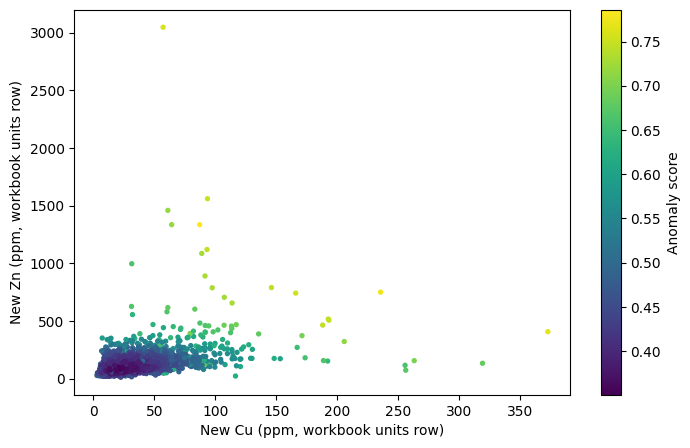

,Unique ID,Cu,Zn,U,anomaly_score
3197,023J781325,87.22,1334.8,21.6,0.785948
2117,014D783298,235.67,750.2,5.9,0.777377
2932,023I823079,372.97,407.6,10.9,0.766432
3328,023J783145,57.23,3046,16.7,0.759367
3056,023J781134,166.05,741.7,3.5,0.752642
3405,023J783240,93.62,1559.8,4.5,0.749043
2941,023I823092,193.3,506.8,4.9,0.748474
2448,023I781043,192.79,517,2.7,0.745946
3212,023J783007,146.13,789.8,2.6,0.744744
3208,023J783002,93.27,1119.5,3,0.744451


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
features=new[['Cu','Zn','U']].apply(pd.to_numeric,errors='coerce')
complete=features.notna().all(axis=1)
features.isna().sum().rename('non_numeric_or_missing').to_csv(OUT/'feature_exclusions.csv')
X=StandardScaler().fit_transform(features.loc[complete])
detector=IsolationForest(contamination=.02,random_state=SEED).fit(X)
rank=new.loc[complete,['Unique ID','Cu','Zn','U']].copy()
rank['anomaly_score']=-detector.score_samples(X)
rank.sort_values('anomaly_score',ascending=False).to_csv(OUT/'baseline_anomaly_ranking.csv',index=False)
fig,ax=plt.subplots(figsize=(8,5));p=ax.scatter(features.loc[complete,'Cu'],features.loc[complete,'Zn'],c=rank.anomaly_score,s=8);fig.colorbar(p,ax=ax,label='Anomaly score');ax.set(xlabel='New Cu (ppm, workbook units row)',ylabel='New Zn (ppm, workbook units row)');save_figure(fig,'anomaly_feature_view')
display(rank.nlargest(10,'anomaly_score'))


In [7]:
# Add your Q3 checks, experiments and required file exports here.
# Use OUT for saved tables and PDF/PNG figures.

# Q3.1:
features = new[['Cu', 'Zn', 'U']].apply(pd.to_numeric, errors='coerce')
complete = features.notna().all(axis=1)
features.isna().sum().rename('non_numeric_or_missing').to_csv(OUT/'feature_exclusions.csv')
X = StandardScaler().fit_transform(features.loc[complete])
detector = IsolationForest(contamination=.02, random_state=SEED).fit(X)
rank = new.loc[complete, ['Unique ID', 'Cu', 'Zn', 'U']].copy()
rank['anomaly_score'] = -detector.score_samples(X)
rank['anomaly_rank'] = rank['anomaly_score'].rank(ascending=False, method='min').astype(int)
rank['is_anomaly'] = detector.predict(X) == -1
rank.sort_values('anomaly_score', ascending=False).to_csv(OUT/'baseline_anomaly_ranking.csv', index=False)


# Q3.2:

def censor_to_half_dl(series):
    s = series.astype(str).str.strip()
    is_censored = s.str.match(r'^[<]')
    dl = pd.to_numeric(s.str.replace('<', '', regex=False), errors='coerce')
    numeric = pd.to_numeric(series, errors='coerce')
    return numeric.where(~is_censored, dl / 2), is_censored

alt_elements = ['Cu', 'Zn', 'U', 'As']
features_alt = pd.DataFrame({c: censor_to_half_dl(new[c])[0] for c in alt_elements})
complete_alt = features_alt.notna().all(axis=1)

X_alt = StandardScaler().fit_transform(features_alt.loc[complete_alt])
detector_alt = IsolationForest(contamination=.02, random_state=SEED).fit(X_alt)
rank_alt = new.loc[complete_alt, ['Unique ID']].copy()
for c in alt_elements:
    rank_alt[c] = features_alt.loc[complete_alt, c]
rank_alt['anomaly_score'] = -detector_alt.score_samples(X_alt)
rank_alt['anomaly_rank'] = rank_alt['anomaly_score'].rank(ascending=False, method='min').astype(int)
rank_alt['is_anomaly'] = detector_alt.predict(X_alt) == -1
rank_alt.to_csv(OUT/'alternative_anomaly_ranking.csv', index=False)

# Q3.3:

both_eligible = list(set(rank['Unique ID']) & set(rank_alt['Unique ID']))
cmp = (rank.set_index('Unique ID')[['anomaly_score', 'anomaly_rank', 'is_anomaly']]
       .join(rank_alt.set_index('Unique ID')[['anomaly_score', 'anomaly_rank', 'is_anomaly']],
             lsuffix='_baseline', rsuffix='_alt', how='inner')).loc[both_eligible]
cmp['rank_change'] = (cmp['anomaly_rank_baseline'] - cmp['anomaly_rank_alt']).abs()
cmp['classification_disagrees'] = cmp['is_anomaly_baseline'] != cmp['is_anomaly_alt']

disagreements = cmp[cmp['classification_disagrees']]
if len(disagreements) >= 5:
    five = disagreements.nlargest(5, 'rank_change')
    note = 'selected on classification disagreement'
elif len(disagreements) > 0:
    five = pd.concat([disagreements, cmp.drop(disagreements.index).nlargest(5 - len(disagreements), 'rank_change')])
    note = f'{len(disagreements)} disagreement(s) found; topped up by largest rank change'
else:
    five = cmp.nlargest(5, 'rank_change')
    note = 'no classification disagreements found; selected on largest rank change (reported honestly)'

print(five[['anomaly_rank_baseline', 'anomaly_rank_alt', 'rank_change',
            'is_anomaly_baseline', 'is_anomaly_alt']])



## Q3.4:
five_ids = five.index.tolist()
rows = []
for uid in five_ids:
    rj = joined[joined['Unique ID'] == uid]          # this ID's row in the Q2 joined table
    b = rank.set_index('Unique ID').loc[uid]          # this ID's baseline score/rank
    a = rank_alt.set_index('Unique ID').loc[uid]       # this ID's alternative score/rank

    rec = {'Unique ID': uid}
    for c in ['Cu', 'Zn', 'U', 'As']:
        rec[f'{c}_new_value'] = new.set_index('Unique ID')[c].get(uid, np.nan)
        rec[f'{c}_new_unit'] = units.get(c, 'not documented')            # NEW's units row, from Q1
        rec[f'{c}_old_value'] = rj[f'{c}_old'].values[0] if len(rj) else None
        rec[f'{c}_old_unit'] = 'not documented in source'                # per Q1.2: OLD has no units row

    rec['baseline_score'] = b['anomaly_score']
    rec['baseline_rank'] = int(b['anomaly_rank'])
    rec['baseline_is_anomaly'] = bool(b['is_anomaly'])
    rec['alt_score'] = a['anomaly_score']
    rec['alt_rank'] = int(a['anomaly_rank'])
    rec['alt_is_anomaly'] = bool(a['is_anomaly'])

    rec['decision'] = ''
    rec['reason'] = ''
    rec['unresolved_evidence'] = ''
    rows.append(rec)

decisions_df = pd.DataFrame(rows)
decisions_df.to_csv(OUT/'anomaly_decisions.csv', index=False)

decisions = {
 '023J783119': ('query',
   'Cu (26.4 vs 21, x1.26) and Zn (146.8 vs 138, x1.06) are close to OLD, consistent with '
   'normal resampling variation. As is nearly double (37.9 vs 19 ppm, x1.99), which is why '
   'the alternative detector but not the baseline flags this record.',
   'No documented As method or detection-limit change between OLD and NEW surveys.'),
 '023J783064': ('query',
   'Cu (18.2 vs 17) and Zn (166.5 vs 164) are essentially unchanged. As more than doubles '
   '(32.9 vs 14 ppm, x2.35), the largest relative As increase in this set.',
   'Same as above: cannot confirm whether x2.35 for As is a real change or a reporting artifact.'),
 '023J783235': ('retain',
   'Cu (32.1 vs 34) and Zn (202.1 vs 220) are both slightly lower in NEW, the opposite '
   'direction to the As shift (33.5 vs 24, x1.40), the smallest As increase in this set. '
   'Mixed direction across elements looks like normal sample variability, not one cause.',
   'U change (1.5 vs 2.8) is unexplained and not investigated further here.'),
 '023J783249': ('retain',
   'Cu (43.9 vs 42) and Zn (193.0 vs 184) both match closely. As (43.3 vs 32, x1.35) is the '
   'smallest relative As increase of the five, and this record has the highest absolute '
   'Cu/Zn/As, consistent with genuine mineralisation rather than a measurement problem.',
   'Cannot confirm from the workbooks alone whether this is a known mineralised zone.'),
 '023J783026': ('query',
   'Cu (29.1 vs 26) and Zn (224.6 vs 205) are modestly higher but consistent. As is the most '
   'extreme in this set (35.4 vs 14, x2.53).',
   'The x2.53 shift is large enough to warrant checking the original NEW lab certificate.'),
}

for uid, (dec, reason, unresolved) in decisions.items():
    mask = decisions_df['Unique ID'] == uid
    decisions_df.loc[mask, 'decision'] = dec
    decisions_df.loc[mask, 'reason'] = reason
    decisions_df.loc[mask, 'unresolved_evidence'] = unresolved

decisions_df.to_csv(OUT/'anomaly_decisions.csv', index=False)
print(decisions_df[['Unique ID', 'decision']])





            anomaly_rank_baseline  anomaly_rank_alt  rank_change  \
Unique ID                                                          
023J783119                   1939                51         1888   
023J783064                   1285                62         1223   
023J783235                   1151                59         1092   
023J783249                    942                35          907   
023J783026                    772                34          738   

            is_anomaly_baseline  is_anomaly_alt  
Unique ID                                        
023J783119                False            True  
023J783064                False            True  
023J783235                False            True  
023J783249                False            True  
023J783026                False            True  
    Unique ID decision
0  023J783119    query
1  023J783064    query
2  023J783235   retain
3  023J783249   retain
4  023J783026    query


### Your Q3 response

3.1) 1 of 3,441 NEW samples excluded from the Cu-Zn-U feature matrix. StandardScaler was used for scaling, For detector IsolationForest(contamination=0.02, random_state=SEED), SEED=9172. Saved to baseline_anomaly_ranking.csv.

3.2) Feature set extended to Cu-Zn-U-As, with As's 1,142 <DL censored entries substituted at DL/2 rather than dropped, since As is the only chosen chemical with heavy censoring in NEW and a pure censored value treatment on Cu/Zn/U alone would be a no as they have zero censored entries. 3,440 eligible, same as baseline.

Q3.3) 52 of 3,440 eligible records genuinely disagree in classification between the two runs. Five compared IDs, selected on largest rank change among disagreements: 023J783119, 023J783064, 023J783235, 023J783249, 023J783026. All five: baseline = not anomalous, alternative = anomalous.

3.4)The five records were selected because they showed the largest changes in anomaly ranking between the baseline model using Cu, Zn and U and the alternative model that also included As. The anomaly status was used to identify records for investigation, not as sufficient evidence for exclusion.

023J783119 — Query: This record changed from baseline rank 1939 to alternative rank 51, a change of 1888 places, and changed from non-anomalous to anomalous. Cu increased from 21 to 26.4 and Zn from 138 to 146.8, which are relatively close to the OLD values. However, As almost doubled from 19 to 37.9 ppm. It was therefore flagged for further investigation, particularly because the As analytical method or detection-limit treatment is undocumented.

023J783064 — Query: Its rank changed from 1285 to 62 and its status changed to anomalous. Cu and Zn remained very similar, while As increased from 14 to 32.9 ppm—a 2.35× increase, the largest relative As increase among these records. This warrants checking the original NEW laboratory result.

023J783235 — Retain: Although its rank changed from 1151 to 59, Cu and Zn decreased slightly while As increased from 24 to 33.5 ppm. The mixed direction across elements does not provide sufficient evidence for exclusion. Its unexplained U change remains an unresolved issue.

023J783249 — Retain: Its rank changed from 942 to 35, but Cu and Zn remained close to the OLD values. Its relatively high absolute Cu, Zn and As values are consistent with possible genuine mineralisation, so it was retained.

023J783026 — Query: Its rank changed from 772 to 34 and As increased from 14 to 35.4 ppm. Cu and Zn showed more modest increases. The large As change justifies checking the original NEW laboratory certificate.

Overall, query means further evidence is needed; retain means there was insufficient evidence to exclude the record.


<h2 style="color:#003B7A;border-left:6px solid #FFC000;padding-left:12px">Q4. Is the workflow reproducible, and which choice do you defend? · 4 marks</h2>

**Q4.1.** Restart the runtime and run your completed notebook from the beginning. Verify every requested output was recreated. Include a manifest with input hashes, student number/seed, library versions and your configuration.

**Q4.2.** Write a 150–250 word decision log comparing your preferred workflow with one rejected alternative. Quote one numerical consequence, such as a changed eligible count or anomaly rank, and explain why it matters.

**Q4.3.** State one unresolved limitation and declare any assistance, including AI, code reuse and discussion. If no assistance was used, say so. Check the submission list below.

**Marking criteria:** Rerun and manifest: 2; rejected alternative and numerical consequence: 1; clear explanation and assistance declaration: 1.

**What good work looks like:** Another person can reproduce your files and understand the decision without reconstructing undocumented manual edits.


### Your Q4 recommendation and assistance declaration

4.2) Both workflows produced 3,440 eligible records, so the alternative did not increase the number of eligible records. However, the anomaly classifications changed substantially: 52 of the 3,440 records were classified differently.

This matters because the choice of feature set and censoring treatment can materially change which samples are prioritised for investigation, even when the number of eligible records remains unchanged. I therefore prefer the alternative as an investigation workflow because it incorporates the available As information rather than discarding censored observations.

4.3)One unresolved limitation is that the OLD workbook does not document the analytical units or analytical methods for the chemical results, while the NEW workbook records PPM for the selected elements. Therefore, differences between OLD and NEW assay values cannot be confidently interpreted as true geochemical changes without additional laboratory or method metadata. Similarly, the OLD and NEW coordinates use NAD83 and NAD27 respectively, and no documented transformation parameters are supplied.

Assistance declaration:I used the practical notebooks from week 1 and 2 to help me. I also used Claude to help me better understand the code and to reword some of my answers.


## Submission checklist

Submit STUDENT_A1.ipynb with outputs; STUDENT_A1_Report.pdf (maximum 1,200 words excluding captions/tables/references); audit.csv; data_dictionary.csv; new_workbook_metadata_rows.csv; joined_samples.csv; join_counts.csv; five_sample_trace.csv; anomaly_decisions.csv; run_manifest.json; and Figures.zip containing PDF/PNG plots. No 3D view is required for these tables. Use your student number in place of STUDENT. The report synthesises the answers; do not add a second unrelated essay. Word limits exclude tables, captions, references and code. Keep your detailed evidence in the notebook. Save 2D figures as PDF and PNG below os.getcwd(); no 3D view is required for these assignments.

- Answer every numbered subquestion.
- Save each named output and check that it opens.
- Include actual evidence for each interpretation.
- Run the archive cell only after completing your work.


In [8]:
import shutil
archive=shutil.make_archive(str(OUT),'zip',root_dir=OUT)
print('Download your evidence:',archive)


Download your evidence: /content/Outputs.zip
